## 1. Data Loading & Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')
df_raw = pd.read_excel("../data/raw/Online Retail.xlsx")
df = df_raw.copy()

In [2]:
print(df.shape)
print()
print(df.info())
print()
print(df.head())

(541909, 8)

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB
None

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3   

## 2. Data Cleaning

In [3]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
df = df.dropna(subset=['CustomerID'])

In [5]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [6]:
df[df['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [7]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C', na=False)]

In [8]:
df[df['Quantity'] < 0].shape[0]

0

In [9]:
df[df['InvoiceNo'].astype(str).str.startswith('C', na=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [10]:
df[df['UnitPrice']<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [11]:
df = df[df['UnitPrice'] > 0]

In [12]:
df.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


## 3. RFM Feature Engineering

In [13]:
date_for_r = df['InvoiceDate'].max() + pd.Timedelta(days=1)
date_for_r

Timestamp('2011-12-10 12:50:00')

In [14]:
recency_df = df.groupby('CustomerID').agg({'InvoiceDate': lambda x: (date_for_r - x.max()).days}).reset_index()

In [15]:
recency_df.rename(columns={'InvoiceDate': 'Recency'}, inplace=True)
recency_df

,CustomerID,Recency
0,12346.0,326
1,12347.0,2
2,12348.0,75
3,12349.0,19
4,12350.0,310
...,...,...
4333,18280.0,278
4334,18281.0,181
4335,18282.0,8
4336,18283.0,4


In [16]:
frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index(name='Frequency')

In [17]:
frequency_df

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4333,18280.0,1
4334,18281.0,1
4335,18282.0,2
4336,18283.0,16


In [18]:
df['TotalPrice'] = df['Quantity']*df['UnitPrice']

In [19]:
monetary_df = df.groupby('CustomerID')['TotalPrice'].sum().reset_index(name='Monetary')

In [20]:
monetary_df

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4333,18280.0,180.60
4334,18281.0,80.82
4335,18282.0,178.05
4336,18283.0,2094.88


In [21]:
rfm = pd.merge(recency_df, frequency_df, on='CustomerID')
rfm = pd.merge(rfm, monetary_df, on='CustomerID')
print(rfm.info())
rfm.head()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   float64
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB
None


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## 4. Feature Preparation (Skew & Scaling)

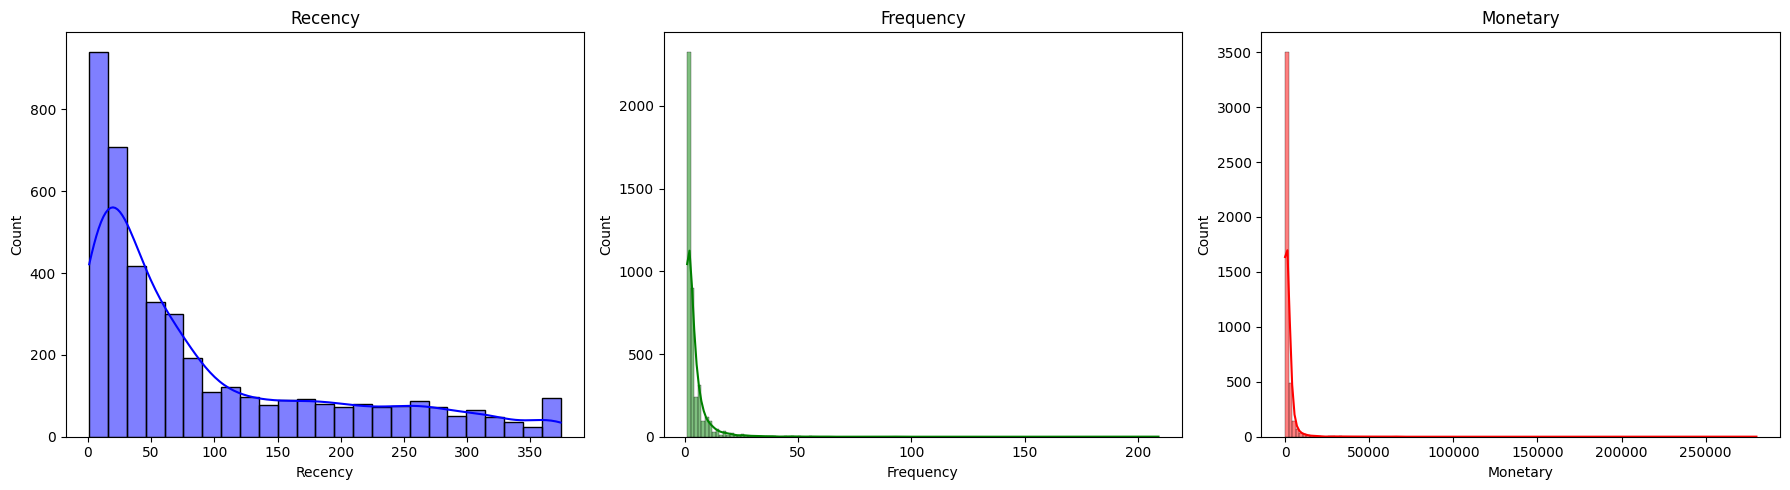

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Recency')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Frequency')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Monetary')

plt.tight_layout()
plt.savefig('../outputs/rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print("Recency Skewness:  ", rfm['Recency'].skew())
print("Frequency Skewness:", rfm['Frequency'].skew())
print("Monetary Skewness: ", rfm['Monetary'].skew())

Recency Skewness:   1.2460475158158468
Frequency Skewness: 12.067030826322075
Monetary Skewness:  19.32495323682082


In [24]:
rfm_features = rfm.set_index('CustomerID')
rfm_log = np.log1p(rfm_features)
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=rfm_features.columns, index=rfm_features.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.706225
12347.0,-2.038734,1.074425,1.411843
12348.0,0.373104,0.386304,0.716489
12349.0,-0.623086,-0.955214,0.698739
12350.0,1.424558,-0.955214,-0.618962


In [25]:
if 'CustomerID' in rfm.columns:
    rfm.set_index('CustomerID', inplace=True)

## 5. Clustering & Model Comparison

k=2: silhouette=0.4329
k=3: silhouette=0.3365
k=4: silhouette=0.3371
k=5: silhouette=0.3161
k=6: silhouette=0.3133
k=7: silhouette=0.3100
k=8: silhouette=0.3008
k=9: silhouette=0.2817
k=10: silhouette=0.2787


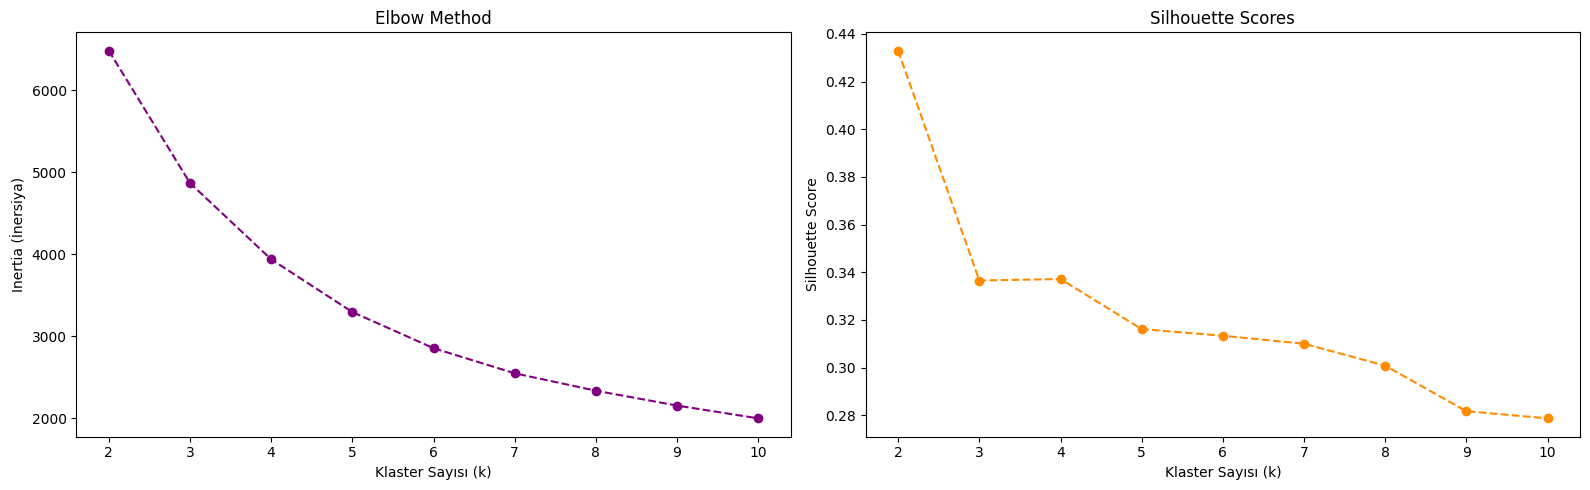

In [26]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

for k, score in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette={score:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(k_range, inertias, marker='o', color='purple', linestyle='--')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Klaster Sayısı (k)')
ax[0].set_ylabel('Inertia (İnersiya)')
ax[0].set_xticks(list(k_range))

ax[1].plot(k_range, silhouette_scores, marker='o', color='darkorange', linestyle='--')
ax[1].set_title('Silhouette Scores')
ax[1].set_xlabel('Klaster Sayısı (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_xticks(list(k_range))

plt.tight_layout()
plt.savefig('../outputs/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(rfm_scaled)
rfm['Cluster'] = cluster_labels
print(rfm['Cluster'].value_counts())

Cluster
1    1872
2    1696
0     770
Name: count, dtype: int64


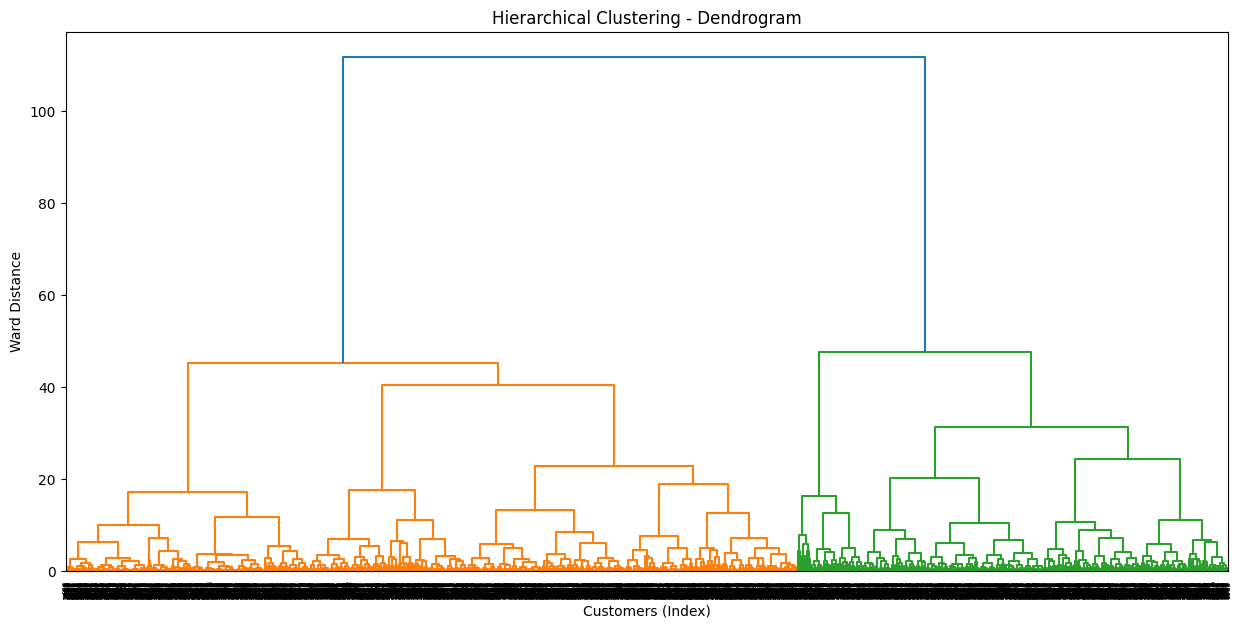

Agglomerative Cluster Distribution:
Agg_Cluster
0    2732
1    1364
2     242
Name: count, dtype: int64


In [28]:
plt.figure(figsize=(15, 7))
dendrogram = sch.dendrogram(sch.linkage(rfm_scaled, method='ward'))
plt.title('Hierarchical Clustering - Dendrogram')
plt.xlabel('Customers (Index)')
plt.ylabel('Ward Distance')
plt.savefig('../outputs/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
agg_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
rfm['Agg_Cluster'] = agg_model.fit_predict(rfm_scaled)

print("Agglomerative Cluster Distribution:")
print(rfm['Agg_Cluster'].value_counts())

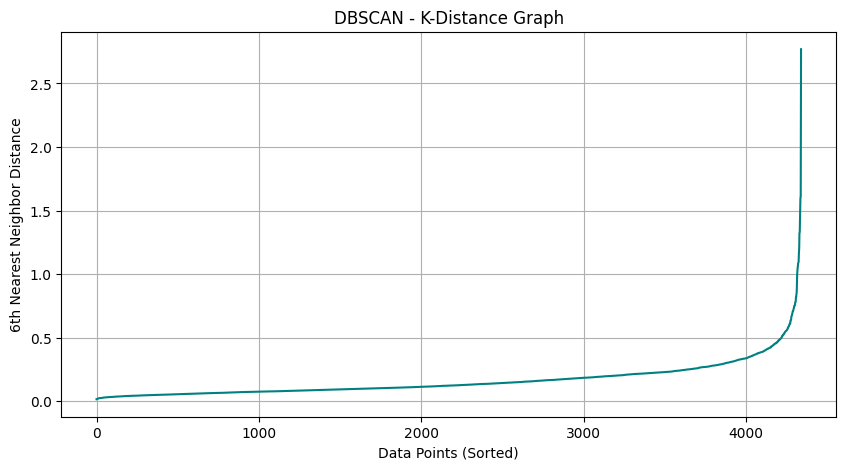

DBSCAN Cluster & Noise Distribution:
DBSCAN_Cluster
 0    2775
 1    1482
-1      81
Name: count, dtype: int64


In [29]:
neighbors = NearestNeighbors(n_neighbors=6)
neighbors_fit = neighbors.fit(rfm_scaled)
distances, indices = neighbors_fit.kneighbors(rfm_scaled)
distances = np.sort(distances[:, 5], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, color='teal')
plt.title('DBSCAN - K-Distance Graph')
plt.xlabel('Data Points (Sorted)')
plt.ylabel('6th Nearest Neighbor Distance')
plt.grid(True)
plt.savefig('../outputs/dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

dbscan_model = DBSCAN(eps=0.45, min_samples=6)
rfm['DBSCAN_Cluster'] = dbscan_model.fit_predict(rfm_scaled)

print("DBSCAN Cluster & Noise Distribution:")
print(rfm['DBSCAN_Cluster'].value_counts())

                       Model  Silhouette Score
                     K-Means          0.336510
Hierarchical (Agglomerative)          0.352555
      DBSCAN (Density-Based)          0.294570


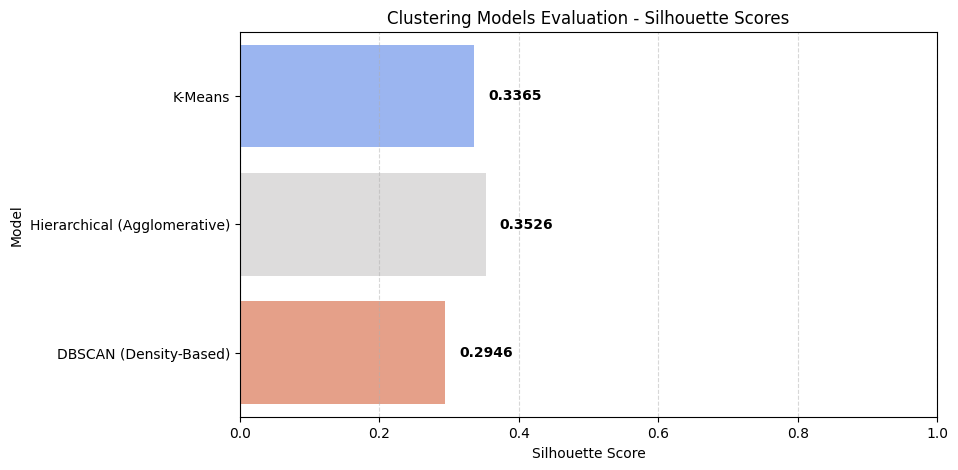

In [30]:
score_kmeans = silhouette_score(rfm_scaled, rfm['Cluster'])
score_agg = silhouette_score(rfm_scaled, rfm['Agg_Cluster'])

dbscan_mask = rfm['DBSCAN_Cluster'] != -1

if rfm.loc[dbscan_mask, 'DBSCAN_Cluster'].nunique() > 1:
    score_dbscan = silhouette_score(rfm_scaled[dbscan_mask], rfm.loc[dbscan_mask, 'DBSCAN_Cluster'])
else:
    score_dbscan = None

comparison_df = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical (Agglomerative)', 'DBSCAN (Density-Based)'],
    'Silhouette Score': [score_kmeans, score_agg, score_dbscan]
})

print(comparison_df.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(x='Silhouette Score', y='Model', data=comparison_df, palette='coolwarm')
plt.title('Clustering Models Evaluation - Silhouette Scores')
plt.xlim(0, 1)

for index, value in enumerate(comparison_df['Silhouette Score']):
    if value is not None:
        plt.text(value + 0.02, index, f'{value:.4f}', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

K-Means (k=3) is our final model: Hierarchical scored slightly higher (0.3526 vs 0.3365) but the gap is small, K-Means gives 3 clear business groups (VIP, Regular, Lost customers), it works better than DBSCAN which only found 2 groups, and it is fast and easy to reuse on new data.it easily.it easily.

## 6. Cluster Profiling & Visualization

In [31]:
cluster_profiles = rfm.groupby('Cluster').agg({'Recency': 'mean','Frequency': 'mean','Monetary': 'mean'}).assign(Customer_Count = rfm['Cluster'].value_counts())
print(cluster_profiles)

            Recency  Frequency     Monetary  Customer_Count
Cluster                                                    
0         17.063636  13.338961  7905.440519             770
1        167.361111   1.352030   362.537613            1872
2         44.212264   3.378538  1265.063852            1696


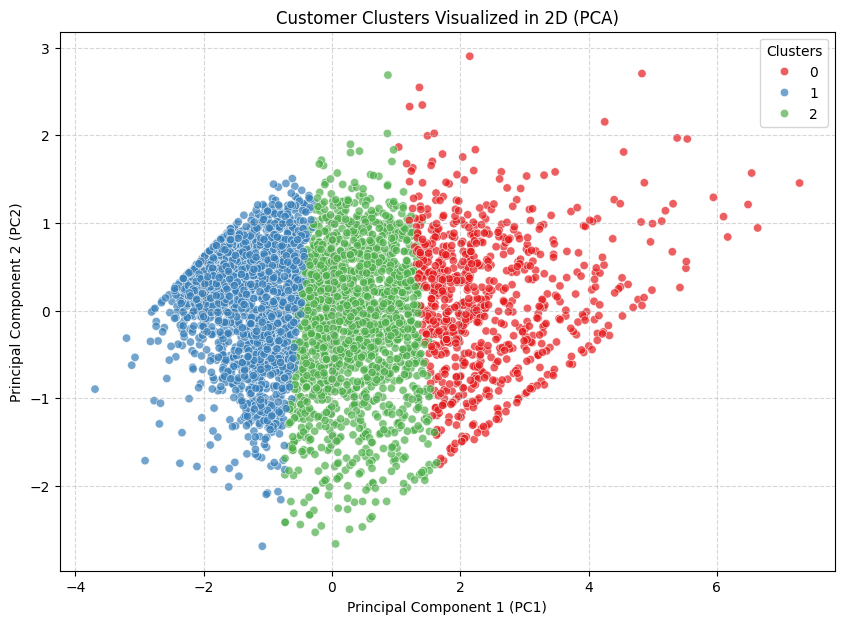

In [32]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled.drop(columns=['Cluster'], errors='ignore'))
pca_df = pd.DataFrame(data=rfm_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm['Cluster'].values
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='Set1', data=pca_df, alpha=0.7)
plt.title('Customer Clusters Visualized in 2D (PCA)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Clusters')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('../outputs/pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
correct_mapping = {
    0: 'VIP / Champions',
    2: 'Regular / Loyal',
    1: 'At Risk / Hibernating'
}
rfm['Customer_Segment'] = rfm['Cluster'].map(correct_mapping)
print(rfm['Customer_Segment'].value_counts())

Customer_Segment
At Risk / Hibernating    1872
Regular / Loyal          1696
VIP / Champions           770
Name: count, dtype: int64


In [34]:
rfm.to_csv('../data/processed/rfm_with_clusters.csv')